# 종합 실습

## 라이브러리, 데이터 불러오기



In [598]:
## 라이브러리 불러오기
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error

import statsmodels.api as sm

In [599]:
## 분석 데이터 로드
df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 데이터 탐색 (분포도 및 박스플롯)

In [600]:
## 데이터 구조 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [601]:
##기초 통계량 확인
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [602]:
## 결측치 확인
df.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


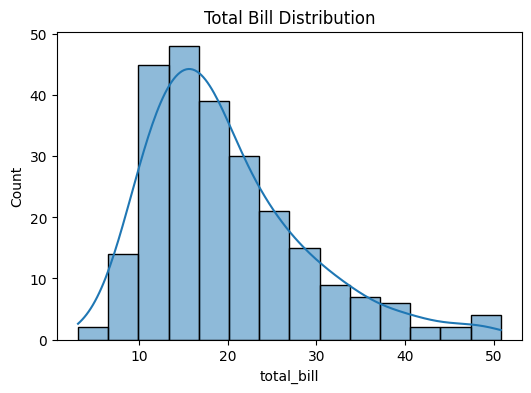

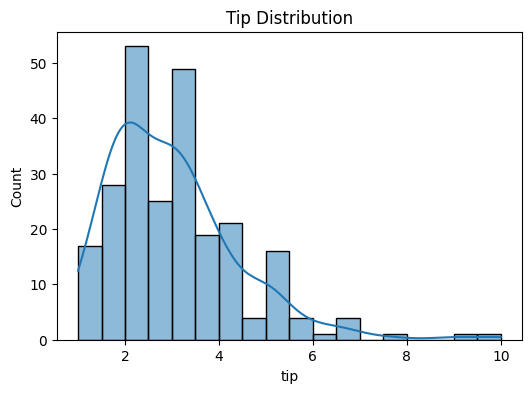

In [603]:
## 데이터 분포 확인
plt.figure(figsize=(6,4))
sns.histplot(df["total_bill"], kde=True)
plt.title("Total Bill Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df["tip"], kde=True)
plt.title("Tip Distribution")
plt.show()

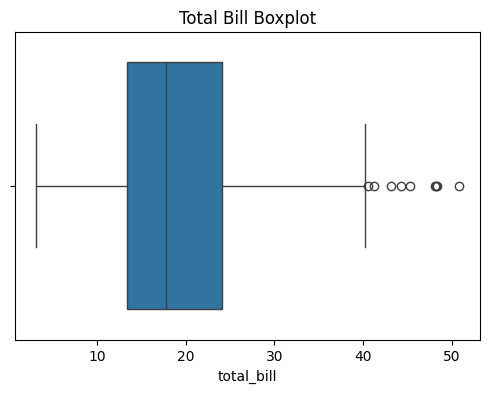

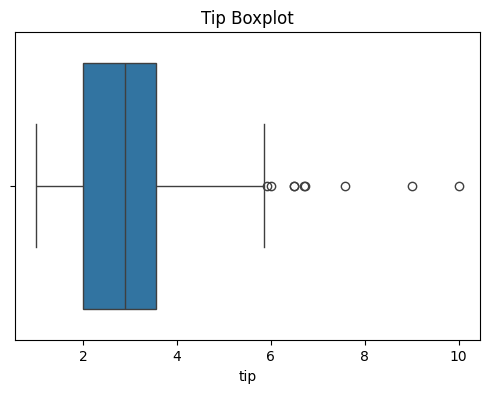

In [604]:
## 박스플롯으로 이상치 확인
plt.figure(figsize=(6,4))
sns.boxplot(x=df["total_bill"])
plt.title("Total Bill Boxplot")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df["tip"])
plt.title("Tip Boxplot")
plt.show()

## 파생 변수 생성
주어진 변수를 조합해, 팁 금액에 영향을 미칠 만한 논리적인 파생 변수를 최소 2개 이상 생성 (ex: 1인당 식사금액, 주말 여부 등)


In [605]:
# ==========================
# 파생 변수 생성
# ==========================

# 1. 1인당 평균 결제금액
#df["bill_per_person"] = df["total_bill"] / df["size"]

# 2. 주말 여부
df["is_weekend"] = df["day"].isin(["Sat", "Sun"]).astype(int)

# 3. 4인 이상 단체 여부
df["is_large_group"] = (df["size"] >= 4).astype(int)

# 4. 총 결제금액 로그 변환
#df["log_total_bill"] = np.log1p(df["total_bill"])

# 5. 총 결제금액과 인원수의 상호작용
#df["bill_size"] = df["total_bill"] * df["size"]

# 6. 고액 결제 여부
median_bill = df["total_bill"].median()
df["high_bill"] = (df["total_bill"] >= median_bill).astype(int)

1인 식사 금액, 주말 여부, 총 식사 금액의 로그 변환, 총 식사금액 * 인원수, 1인당 식사금액 구간 등의 변수를 추가한 결과

위 2가지(주말 여부, 4인 이상 단체 여부)를 적용 했을 때 MAPE가 가장 낮게 나옴.

In [606]:
##확인
df.head()

,total_bill,tip,sex,smoker,day,time,size,is_weekend,is_large_group,high_bill
0,16.99,1.01,Female,No,Sun,Dinner,2,1,0,0
1,10.34,1.66,Male,No,Sun,Dinner,3,1,0,0
2,21.01,3.50,Male,No,Sun,Dinner,3,1,0,1
3,23.68,3.31,Male,No,Sun,Dinner,2,1,0,1
4,24.59,3.61,Female,No,Sun,Dinner,4,1,1,1


## Data Partition - Train/Test 분리


train_test_split 함수를 사용해 분석용 데이터와 평가용 데이터를 8:2로 분할합니다


In [607]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.3, random_state=42, shuffle=True)

print(train.shape)
print(test.shape)

(170, 10)
(74, 10)


## 데이터 전처리

수업 시간에배운 기법을 활용해 다음 과정을 반드시 포함

-결측치 또는 이상치 탐지 및 처리 (합리적인 기준 적용)

-연속형 변수에 대한 분포 확인 및 스케일링 (Min-Max 또는 Standard)

-범주형 변수에 대한 One-hot Encoding


In [608]:
## 결측치
train.isnull().sum()

## tips 데이터에는 결측치가 없어서 아래 코드 실행 X
## train.fillna(...)

## 이상치
numeric_cols = [ "total_bill", "size" ]

for col in numeric_cols:

    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    train[col] = train[col].clip(lower, upper)
    test[col] = test[col].clip(lower, upper)

In [609]:
# day 컬럼 제거 (is_weekend를 사용할 것이므로 day는 사용하지 않음)
train = train.drop(columns=["day"])
test = test.drop(columns=["day"])

## 범주형 변수에 대한 One-hot Encoding
categorical_cols = ["sex", "smoker", "time"]

## Encoding
train = pd.get_dummies(
    train,
    columns=categorical_cols,
    drop_first=True
)

test = pd.get_dummies(
    test,
    columns=categorical_cols,
    drop_first=True
)


train, test = train.align(
    test,
    join="left",
    axis=1,
    fill_value=0
)

In [610]:
## 스케일링(연속형 변수)
continuous_cols = [ "total_bill", "size" ]

scaler = StandardScaler()

train[continuous_cols] = scaler.fit_transform(train[continuous_cols])

test[continuous_cols] = scaler.transform(test[continuous_cols])

## x,y 분리

In [611]:
X_train = train.drop("tip", axis=1)
y_train = train["tip"]

X_test = test.drop("tip", axis=1)
y_test = test["tip"]

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

# 추가
X_train = X_train.astype(float)
X_test = X_test.astype(float)

model = sm.OLS(y_train, X_train).fit()

## 회귀분석

In [612]:
model = sm.OLS(
    y_train,
    X_train
).fit()

## 결과 확인

In [613]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.441
Method:                 Least Squares   F-statistic:                     17.69
Date:                Tue, 21 Jul 2026   Prob (F-statistic):           8.97e-19
Time:                        08:18:02   Log-Likelihood:                -252.11
No. Observations:                 170   AIC:                             522.2
Df Residuals:                     161   BIC:                             550.4
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              2.9270      0.280     10.

## 예측

In [614]:
pred = model.predict(X_test)

## MAPE 계산

In [615]:
mape = mean_absolute_percentage_error(
    y_test,
    pred
)

print(f"MAPE : {mape:.4f}")
print(f"MAPE : {mape*100:.2f}%")

MAPE : 0.2780
MAPE : 27.80%


## 실제값과 예측값 비교

In [616]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": pred
})

result.head(10)

,Actual,Predicted
24,3.18,3.078340
6,2.00,1.909038
153,2.00,4.108671
211,5.16,3.972973
198,2.00,2.096761
176,2.00,2.662103
192,2.56,3.706191
124,2.52,2.302808
9,3.23,2.424645
101,3.00,2.253962


## 산점도로 시각화

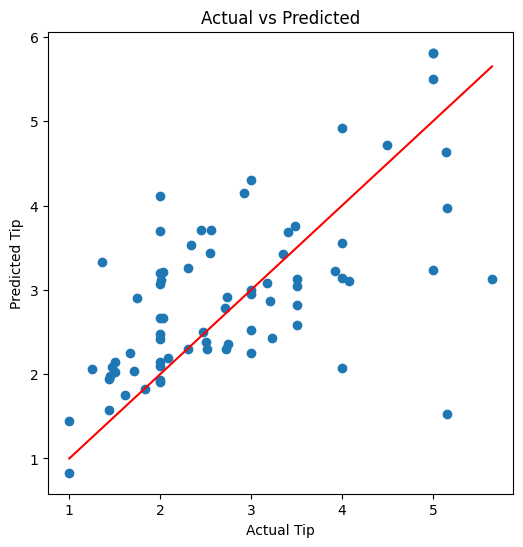

In [617]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, pred)

plt.xlabel("Actual Tip")
plt.ylabel("Predicted Tip")
plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

## 다중공선성 확인
VIF를 계산하여 확인

In [618]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# 설명변수 선택
X = train.drop("tip", axis=1).astype(float)

# 상수항 추가
X = sm.add_constant(X)

# VIF 계산
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif.sort_values("VIF", ascending=False))

         Variable        VIF
0           const  11.095941
2            size   6.237490
4  is_large_group   5.296262
3      is_weekend   4.457038
8     time_Dinner   4.346407
1      total_bill   3.070855
5       high_bill   2.651558
7       smoker_No   1.096174
6      sex_Female   1.082067


## 엑셀 파일 제출용

In [619]:
corr = df.corr(numeric_only=True)

corr["tip"].sort_values(key=abs, ascending=False)

,tip
tip,1.000000
total_bill,0.675734
high_bill,0.530935
size,0.489299
is_large_group,0.425938
is_weekend,0.120198


In [620]:
import numpy as np

corr = df.corr(numeric_only=True).abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

pairs = (
    upper.stack()
    .sort_values(ascending=False)
)

print(pairs.head(10))

size            is_large_group    0.869868
total_bill      high_bill         0.746342
                tip               0.675734
                size              0.598315
tip             high_bill         0.530935
total_bill      is_large_group    0.516835
size            high_bill         0.496562
tip             size              0.489299
is_large_group  high_bill         0.461043
tip             is_large_group    0.425938
dtype: float64


In [621]:
#Test MAPE
mape = mean_absolute_percentage_error(
    y_test,
    pred
)

print(f"MAPE : {mape:.4f}")
print(f"MAPE : {mape*100:.2f}%")

MAPE : 0.2780
MAPE : 27.80%


In [622]:
#Baseline MAPE
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

baseline_pred = np.repeat(y_train.mean(), len(y_test))
baseline_mape = mean_absolute_percentage_error(y_test, baseline_pred)

print(f"{baseline_mape * 100:.2f}%")

46.60%


In [623]:
#모델 요약
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.441
Method:                 Least Squares   F-statistic:                     17.69
Date:                Tue, 21 Jul 2026   Prob (F-statistic):           8.97e-19
Time:                        08:18:02   Log-Likelihood:                -252.11
No. Observations:                 170   AIC:                             522.2
Df Residuals:                     161   BIC:                             550.4
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              2.9270      0.280     10.